In [1]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_data (3).csv to synthetic_data (3).csv
Saving Bank_Personal_Loan_Modelling.xlsx to Bank_Personal_Loan_Modelling (4).xlsx


In [2]:
import os
print(os.listdir())

['.config', 'Bank_Personal_Loan_Modelling.xlsx', 'Bank_Personal_Loan_Modelling (1).xlsx', 'Bank_Personal_Loan_Modelling (3).xlsx', 'Bank_Personal_Loan_Modelling (4).xlsx', 'Bank_Personal_Loan_Modelling (2).xlsx', 'synthetic_data (3).csv', 'synthetic_data.csv', 'synthetic_data (2) (1).csv', 'synthetic_data (2).csv', 'sample_data']


In [3]:
import pandas as pd

# real
real_df = pd.read_excel("Bank_Personal_Loan_Modelling.xlsx", sheet_name="Data")
real_df = real_df.sample(2000, random_state=42)

# synthetic
syn = pd.read_csv("synthetic_data.csv")

print(real_df.shape)
print(syn.shape)

(2000, 14)
(500, 9)


In [8]:
# real
real_loan = real_df["Mortgage"]
real_loan = real_loan[real_loan > 0]

# synthetic
syn_loan = syn["Loan_Amount"]
syn_loan = syn_loan[syn_loan > 0]

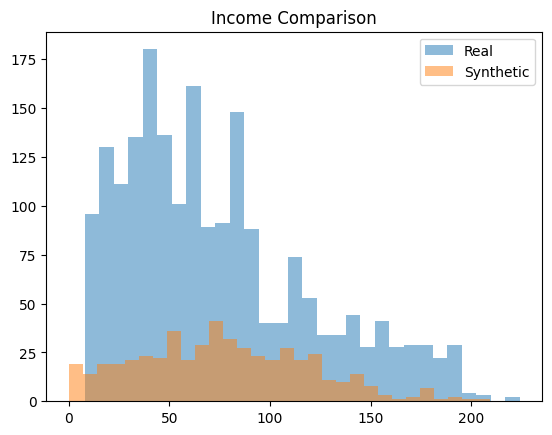

In [9]:
import matplotlib.pyplot as plt

plt.hist(real_df["Income"], bins=30, alpha=0.5, label="Real")
plt.hist(syn["Income"], bins=30, alpha=0.5, label="Synthetic")

plt.legend()
plt.title("Income Comparison")
plt.show()

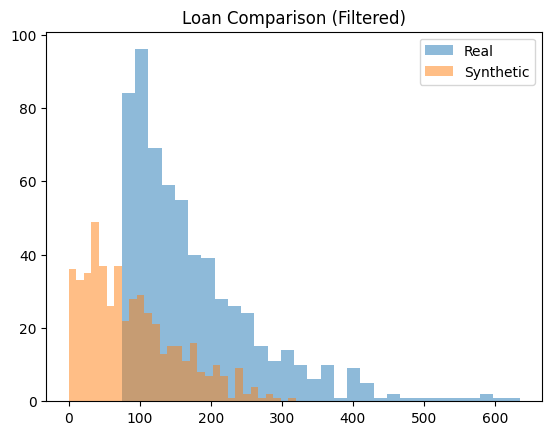

In [10]:
plt.hist(real_loan, bins=30, alpha=0.5, label="Real")
plt.hist(syn_loan, bins=30, alpha=0.5, label="Synthetic")

plt.legend()
plt.title("Loan Comparison (Filtered)")
plt.show()

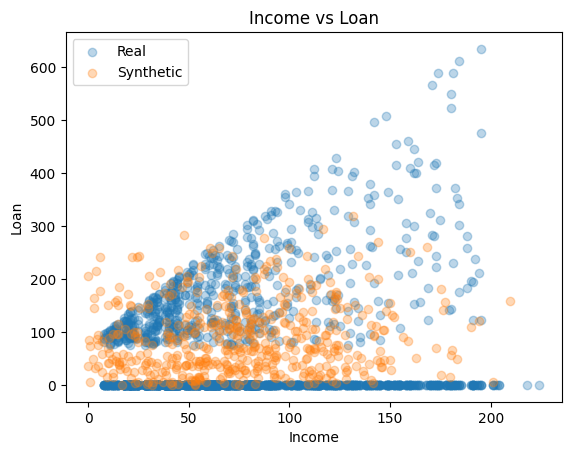

In [11]:
plt.scatter(real_df["Income"], real_df["Mortgage"], alpha=0.3, label="Real")
plt.scatter(syn["Income"], syn["Loan_Amount"], alpha=0.3, label="Synthetic")

plt.legend()
plt.xlabel("Income")
plt.ylabel("Loan")
plt.title("Income vs Loan")
plt.show()

In [12]:
from scipy.stats import ks_2samp

ks_income = ks_2samp(real_df["Income"], syn["Income"])
ks_loan = ks_2samp(real_loan, syn_loan)

print("KS Income:", ks_income)
print("KS Loan (Filtered):", ks_loan)

KS Income: KstestResult(statistic=np.float64(0.123), pvalue=np.float64(1.026767044431875e-05), statistic_location=np.float64(65.0), statistic_sign=np.int8(1))
KS Loan (Filtered): KstestResult(statistic=np.float64(0.510970684039088), pvalue=np.float64(3.9380468658044863e-66), statistic_location=np.float64(77.70670774657374), statistic_sign=np.int8(-1))
